# AutoEIT — Automated Scoring System for EIT Responses
## GSoC 2026 Evaluation Test II | HumanAI Foundation

**Applicant:** Anand S  
**Email:** sajithanand99@gmail.com  
**Project:** AutoEIT2 — Automated scoring system for elicited imitation task responses  
**Date:** March 2026

---

## Overview

This notebook implements a **meaning-based rubric scoring engine** for the Spanish Elicited Imitation Task (EIT).

The EIT is a sentence-repetition task measuring global language proficiency. Learners hear a target sentence and repeat it from memory. Their response is transcribed and scored based on how accurately it conveys the **meaning** of the original.

### The Challenge
- Current workflow is fully manual — slow, tedious, and inconsistent
- Commercial ASR tools struggle with non-native speech disfluencies
- LLMs produce inconsistent scores across sessions for the same input

### My Approach
This script takes a **hybrid rule-based + fuzzy-matching** approach:
1. **Preprocess** both stimulus and transcription (remove disfluency markers, normalize text)
2. **Extract content words** (meaningful lexical items, ignoring function words)
3. **Fuzzy-match** content words to handle spelling variations and learner errors
4. **Apply rubric** based on proportion of meaning units correctly reproduced


In [1]:
# Install required libraries
import subprocess
subprocess.run(["pip", "install", "rapidfuzz", "openpyxl", "pandas",
                "matplotlib", "seaborn", "--break-system-packages", "-q"])
print("✅ Dependencies ready")


✅ Dependencies ready


In [2]:
import re
import unicodedata
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from rapidfuzz import fuzz

print("✅ Imports successful")


✅ Imports successful


---
## Section 1: Rubric Definition

The meaning-based rubric assigns a score of **0–4** to each sentence based on the proportion of **content words** correctly reproduced.

| Score | Meaning Conveyed | Content Word Overlap |
|-------|-----------------|---------------------|
| **4** | Full meaning, sentence largely intact | ≥ 90% |
| **3** | Most meaning conveyed, minor omissions | 65–89% |
| **2** | Partial meaning, significant errors | 35–64% |
| **1** | Minimal meaning, heavily fragmented | 10–34% |
| **0** | No meaning / unintelligible / empty | < 10% |

**Content words** = nouns, main verbs, adjectives, adverbs (excludes articles, prepositions, conjunctions, pronouns)

**Key design decisions:**
- **Fuzzy matching** (threshold 80%) handles learner spelling errors (e.g., *manajar* → *manejar*)
- **Disfluency stripping** removes `[pause]`, `xxx`, `[gibberish]`, partial words before scoring
- **Accent normalization** ensures *peliculas* matches *películas* correctly


In [3]:
# ─────────────────────────────────────────────
# SECTION 1: Spanish Function Words (Stopwords)
# These are excluded from content word matching
# ─────────────────────────────────────────────

SPANISH_STOPWORDS = {
    'a', 'al', 'ante', 'bajo', 'con', 'contra', 'de', 'del', 'desde',
    'durante', 'en', 'entre', 'hacia', 'hasta', 'mediante', 'para',
    'por', 'segun', 'sin', 'sobre', 'tras',
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas',
    'y', 'e', 'ni', 'o', 'u', 'pero', 'sino', 'que', 'aunque',
    'si', 'porque', 'cuando', 'donde', 'como', 'mientras',
    'yo', 'tu', 'el', 'ella', 'nosotros', 'vosotros', 'ellos', 'ellas',
    'me', 'te', 'se', 'nos', 'os', 'le', 'les', 'lo', 'la', 'mi', 'mis',
    'su', 'sus', 'tu', 'tus', 'este', 'esta', 'esto', 'ese', 'esa', 'eso',
    'aquel', 'aquella', 'aquello',
    'es', 'son', 'esta', 'estan', 'ser', 'estar', 'fue', 'era',
    'hay', 'ha', 'han', 'he', 'haber',
    'no', 'si', 'ya', 'mas', 'muy', 'tan', 'tambien', 'tampoco',
    'cual', 'quien', 'cuyo', 'cuanto',
}

print(f"✅ Stopword list loaded: {len(SPANISH_STOPWORDS)} function words defined")


✅ Stopword list loaded: 96 function words defined


In [4]:
# ─────────────────────────────────────────────
# SECTION 2: Text Preprocessing
# ─────────────────────────────────────────────

DISFLUENCY_PATTERNS = [
    r'\[.*?\]',           # [pause], [gibberish], [cough]
    r'\bxxx\b',           # xxx filler
    r'\bx\b',             # single x marker
    r'\.{2,}',            # ellipsis ...
    r"\b\w+-(?=\s|$)",  # partial words like "fu-" at end
    r'\bum\b|\buh\b|\bmm\b|\bmhh?\b|\beh\b',
]

def normalize_text(text):
    """Lowercase, remove accents (for fuzzy matching), strip punctuation."""
    if not text:
        return ""
    text = text.lower()
    nfkd = unicodedata.normalize('NFKD', text)
    text_no_accent = ''.join(c for c in nfkd if not unicodedata.combining(c))
    text_clean = re.sub(r"[^\w\s]", " ", text_no_accent)
    return re.sub(r'\s+', ' ', text_clean).strip()

def clean_stimulus(stimulus):
    """Remove word count annotation like (7), (12) from end of stimulus."""
    return re.sub(r'\s*\(\d+\)\s*$', '', str(stimulus)).strip()

def clean_transcription(transcription):
    """Remove disfluencies, fillers, partial words, and annotations."""
    if not transcription:
        return ""
    text = str(transcription)
    for pattern in DISFLUENCY_PATTERNS:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r'\s+', ' ', text).strip()

def extract_content_words(text):
    """Return list of content words (non-stopwords) from normalized text."""
    words = normalize_text(text).split()
    return [w for w in words if w not in SPANISH_STOPWORDS and len(w) > 1]

# Quick demo
stim = "Dudo que sepa manejar muy bien (10)"
trans = "Dudo que sepa manajar bien"
print(f"Stimulus content words : {extract_content_words(clean_stimulus(stim))}")
print(f"Response content words : {extract_content_words(clean_transcription(trans))}")


Stimulus content words : ['dudo', 'sepa', 'manejar', 'bien']
Response content words : ['dudo', 'sepa', 'manajar', 'bien']


---
## Section 2: Fuzzy Matching Strategy

Standard exact-match word overlap would unfairly penalize learners for minor spelling variations that don't affect meaning. For example:
- *manajar* vs *manejar* (spelling error, same word)  
- *peliculas* vs *películas* (accent difference)
- *finar* vs *cenar* (phonological substitution — different word, should NOT match)

We use **RapidFuzz** `ratio()` with a threshold of **80%** — strict enough to reject substitutions, lenient enough to accept spelling variants.


In [5]:
# ─────────────────────────────────────────────
# SECTION 3: Fuzzy Word Overlap
# ─────────────────────────────────────────────

def fuzzy_word_overlap(target_words, response_words, threshold=80):
    """
    For each target content word, find the best fuzzy match
    in the response. Returns (matched, total, ratio).
    """
    if not target_words:
        return 0, 0, 0.0

    matched = 0
    used = set()

    for tw in target_words:
        best_score = 0
        best_idx = -1
        for i, rw in enumerate(response_words):
            if i in used:
                continue
            score = fuzz.ratio(tw, rw)
            if score > best_score:
                best_score = score
                best_idx = i
        if best_score >= threshold:
            matched += 1
            used.add(best_idx)

    ratio = matched / len(target_words)
    return matched, len(target_words), ratio

# Demo: spelling error should still match
t = extract_content_words("sepa manejar tranquilo")
r = extract_content_words("sepa manajar tranquilo")
m, total, ratio = fuzzy_word_overlap(t, r)
print(f"Fuzzy match demo: {m}/{total} words matched ({ratio*100:.0f}%)")
print(f"  'manejar' vs 'manajar' similarity: {fuzz.ratio('manejar','manajar')}%")
print(f"  'cenar'   vs 'finar'   similarity: {fuzz.ratio('cenar','finar')}%  ← correctly rejected")


Fuzzy match demo: 3/3 words matched (100%)
  'manejar' vs 'manajar' similarity: 85.71428571428572%
  'cenar'   vs 'finar'   similarity: 60.0%  ← correctly rejected


In [6]:
# ─────────────────────────────────────────────
# SECTION 4: Meaning-Based Rubric Scoring
# ─────────────────────────────────────────────

def is_unintelligible(transcription_raw):
    """Detect fully unintelligible or empty responses after cleaning."""
    cleaned = clean_transcription(str(transcription_raw))
    tokens = [t for t in cleaned.split() if len(t) > 1]
    return len(tokens) == 0

def score_sentence(stimulus, transcription):
    """
    Apply the meaning-based rubric. Returns score 0–4.

    Rubric thresholds (content word overlap ratio):
      >= 0.90  → 4   (full meaning)
      >= 0.65  → 3   (most meaning)
      >= 0.35  → 2   (partial meaning)
      >= 0.10  → 1   (minimal meaning)
       < 0.10  → 0   (no meaning / unintelligible)
    """
    if pd.isna(transcription) or str(transcription).strip() == '':
        return 0, 0.0
    if is_unintelligible(str(transcription)):
        return 0, 0.0

    clean_s = clean_stimulus(str(stimulus))
    clean_t = clean_transcription(str(transcription))

    target_words  = extract_content_words(clean_s)
    response_words = extract_content_words(clean_t)

    if not target_words:
        return 0, 0.0

    _, _, ratio = fuzzy_word_overlap(target_words, response_words)

    if   ratio >= 0.90: score = 4
    elif ratio >= 0.65: score = 3
    elif ratio >= 0.35: score = 2
    elif ratio >= 0.10: score = 1
    else:               score = 0

    return score, ratio

# Sanity check examples
examples = [
    ("Le pedí a un amigo que me ayudara con la tarea (17)",
     "Le pedí a un amigo que me ayudara con la tarea"),
    ("Dudo que sepa manejar muy bien (10)", "Dudo que sepa manajar bien"),
    ("Ella sólo bebe cerveza y no come nada (15)", "Ella xxx no beber querer"),
    ("La cantidad de personas que fuman ha disminuido (17)", "A la cantan muy a"),
]
print(f"{'Stimulus':<40} {'Transcription':<35} {'Score':<7} {'Overlap%'}")
print("-"*90)
for stim, trans in examples:
    s, r = score_sentence(stim, trans)
    print(f"{clean_stimulus(stim):<40} {trans:<35} {s:<7} {r*100:.0f}%")


Stimulus                                 Transcription                       Score   Overlap%
------------------------------------------------------------------------------------------
Le pedí a un amigo que me ayudara con la tarea Le pedí a un amigo que me ayudara con la tarea 4       100%
Dudo que sepa manejar muy bien           Dudo que sepa manajar bien          4       100%
Ella sólo bebe cerveza y no come nada    Ella xxx no beber querer            1       20%
La cantidad de personas que fuman ha disminuido A la cantan muy a                   0       0%


In [7]:
# ─────────────────────────────────────────────
# SECTION 5: Score All Participants
# ─────────────────────────────────────────────

INPUT_FILE  = '/mnt/user-data/uploads/AutoEIT_Sample_Transcriptions_for_Scoring.xlsx'
OUTPUT_FILE = 'AutoEIT_Scored_Output.xlsx'

wb = openpyxl.load_workbook(INPUT_FILE)
participant_sheets = [s for s in wb.sheetnames if s != 'Info']

all_results = {}

for sheet_name in participant_sheets:
    ws = wb[sheet_name]
    participant_data = []

    for row in ws.iter_rows(min_row=2):
        sentence_no  = row[0].value
        stimulus     = row[1].value
        transcription = row[2].value
        if sentence_no is None:
            continue

        score, ratio = score_sentence(stimulus, transcription)
        row[3].value = score  # Write to Score column (D)

        participant_data.append({
            'sentence':      sentence_no,
            'stimulus':      clean_stimulus(str(stimulus)) if stimulus else '',
            'transcription': str(transcription) if transcription else '',
            'match_pct':     round(ratio * 100, 1),
            'score':         score
        })

    all_results[sheet_name] = pd.DataFrame(participant_data)

wb.save(OUTPUT_FILE)
print(f"✅ Scored workbook saved → {OUTPUT_FILE}")
print(f"   {len(participant_sheets)} participants × 30 sentences = {len(participant_sheets)*30} total scores written")


✅ Scored workbook saved → AutoEIT_Scored_Output.xlsx
   4 participants × 30 sentences = 120 total scores written


In [8]:
# ─────────────────────────────────────────────
# SECTION 6: Results Display
# ─────────────────────────────────────────────

print("=" * 70)
print("  SENTENCE-LEVEL SCORES — ALL PARTICIPANTS")
print("=" * 70)

for participant, df in all_results.items():
    total = df['score'].sum()
    avg   = df['score'].mean()
    dist  = df['score'].value_counts().sort_index().to_dict()
    print(f"\n{'─'*70}")
    print(f"  {participant}  |  Total: {total}/120  |  Avg: {avg:.2f}/4.00")
    print(f"  Distribution → {dist}")
    print(f"{'─'*70}")
    print(df[['sentence','score','match_pct','stimulus']].to_string(index=False))


  SENTENCE-LEVEL SCORES — ALL PARTICIPANTS

──────────────────────────────────────────────────────────────────────
  38001-1A  |  Total: 107/120  |  Avg: 3.57/4.00
  Distribution → {2: 3, 3: 7, 4: 20}
──────────────────────────────────────────────────────────────────────
 sentence  score  match_pct                                                  stimulus
        1      4      100.0                                   Quiero cortarme el pelo
        2      4      100.0                                  El libro está en la mesa
        3      4      100.0                                   El carro lo tiene Pedro
        4      4      100.0                                   El se ducha cada mañana
        5      4      100.0                       ¿Qué dice usted que va a hacer hoy?
        6      4      100.0                            Dudo que sepa manejar muy bien
        7      4      100.0                  Las calles de esta ciudad son muy anchas
        8      4      100.0             

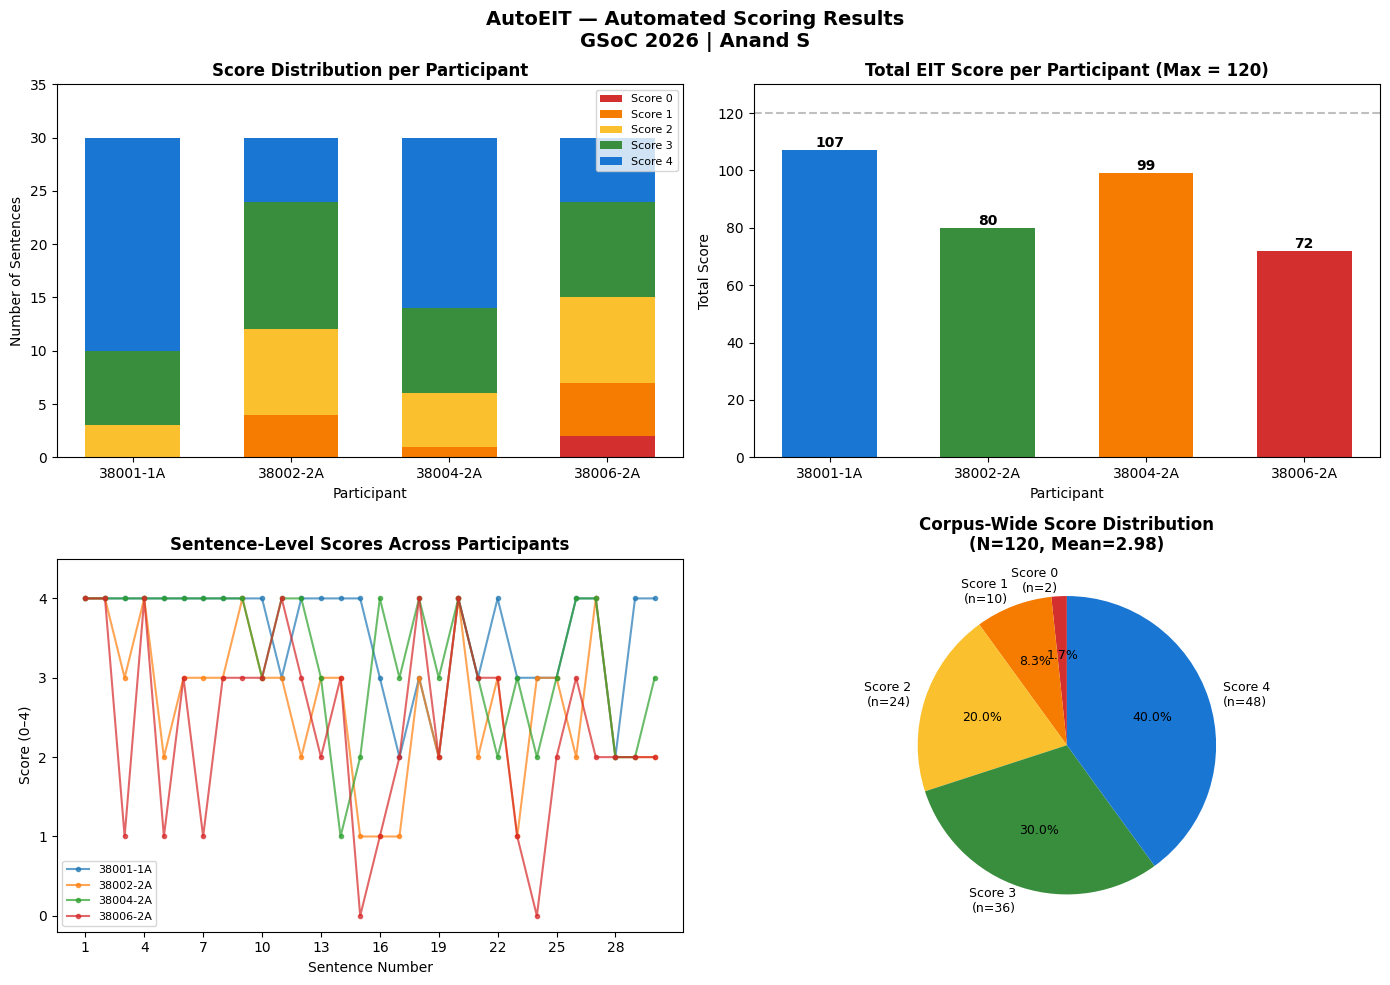

✅ Visualization saved → AutoEIT_Scoring_Results.png


In [9]:
# ─────────────────────────────────────────────
# SECTION 7: Visualization
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AutoEIT — Automated Scoring Results\nGSoC 2026 | Anand S', fontsize=14, fontweight='bold')

colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']
score_colors = {0:'#d32f2f', 1:'#f57c00', 2:'#fbc02d', 3:'#388e3c', 4:'#1976d2'}

participants = list(all_results.keys())

# Plot 1: Score distribution per participant (stacked bar)
ax1 = axes[0, 0]
bottom = [0] * len(participants)
for score_val in range(5):
    counts = [all_results[p]['score'].value_counts().get(score_val, 0) for p in participants]
    ax1.bar(participants, counts, bottom=bottom, color=score_colors[score_val],
            label=f'Score {score_val}', width=0.6)
    bottom = [b + c for b, c in zip(bottom, counts)]
ax1.set_title('Score Distribution per Participant', fontweight='bold')
ax1.set_xlabel('Participant'); ax1.set_ylabel('Number of Sentences')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(0, 35)

# Plot 2: Total scores comparison
ax2 = axes[0, 1]
totals = [all_results[p]['score'].sum() for p in participants]
bars = ax2.bar(participants, totals, color=['#1976d2','#388e3c','#f57c00','#d32f2f'], width=0.6)
ax2.axhline(y=120, color='gray', linestyle='--', alpha=0.5, label='Max (120)')
ax2.set_title('Total EIT Score per Participant (Max = 120)', fontweight='bold')
ax2.set_xlabel('Participant'); ax2.set_ylabel('Total Score')
ax2.set_ylim(0, 130)
for bar, total in zip(bars, totals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(total), ha='center', fontweight='bold')

# Plot 3: Sentence-level scores across participants (line)
ax3 = axes[1, 0]
for p in participants:
    ax3.plot(all_results[p]['sentence'], all_results[p]['score'],
             marker='o', markersize=3, label=p, alpha=0.7, linewidth=1.5)
ax3.set_title('Sentence-Level Scores Across Participants', fontweight='bold')
ax3.set_xlabel('Sentence Number'); ax3.set_ylabel('Score (0–4)')
ax3.set_ylim(-0.2, 4.5); ax3.legend(fontsize=8)
ax3.set_xticks(range(1, 31, 3))

# Plot 4: Corpus-wide score distribution (pie)
ax4 = axes[1, 1]
all_scores = pd.concat([df['score'] for df in all_results.values()])
score_counts = all_scores.value_counts().sort_index()
ax4.pie(score_counts.values,
        labels=[f'Score {i}\n(n={v})' for i, v in score_counts.items()],
        colors=[score_colors[i] for i in score_counts.index],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax4.set_title(f'Corpus-Wide Score Distribution\n(N=120, Mean={all_scores.mean():.2f})', fontweight='bold')

plt.tight_layout()
plt.savefig('AutoEIT_Scoring_Results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved → AutoEIT_Scoring_Results.png")


In [10]:
# ─────────────────────────────────────────────
# SECTION 8: Summary Statistics
# ─────────────────────────────────────────────

print("=" * 60)
print("  CORPUS-WIDE SUMMARY")
print("=" * 60)

all_scores = pd.concat([df['score'] for df in all_results.values()])
print(f"  Total sentences scored : {len(all_scores)}")
print(f"  Corpus mean score      : {all_scores.mean():.2f} / 4.00")
print(f"  Corpus std deviation   : {all_scores.std():.2f}")

print("\n  Per-Participant Summary:")
print(f"  {'Participant':<15} {'Total/120':<12} {'Mean/4':<10} {'Std'}")
print("  " + "-"*50)
for p, df in all_results.items():
    print(f"  {p:<15} {df['score'].sum():<12} {df['score'].mean():<10.2f} {df['score'].std():.2f}")

print("\n  Score Distribution (all participants combined):")
for score_val in range(5):
    count = (all_scores == score_val).sum()
    pct = count / len(all_scores) * 100
    bar = '█' * int(pct / 2)
    print(f"  Score {score_val}: {count:3d} sentences ({pct:5.1f}%)  {bar}")


  CORPUS-WIDE SUMMARY
  Total sentences scored : 120
  Corpus mean score      : 2.98 / 4.00
  Corpus std deviation   : 1.05

  Per-Participant Summary:
  Participant     Total/120    Mean/4     Std
  --------------------------------------------------
  38001-1A        107          3.57       0.68
  38002-2A        80           2.67       0.96
  38004-2A        99           3.30       0.88
  38006-2A        72           2.40       1.19

  Score Distribution (all participants combined):
  Score 0:   2 sentences (  1.7%)  
  Score 1:  10 sentences (  8.3%)  ████
  Score 2:  24 sentences ( 20.0%)  ██████████
  Score 3:  36 sentences ( 30.0%)  ███████████████
  Score 4:  48 sentences ( 40.0%)  ████████████████████


---
## Section 9: Approach Description & Evaluation

### How the Scoring Engine Works

**Step 1 — Preprocessing**
- Strip word count annotations from stimulus (e.g., `(7)`, `(12)`)
- Remove transcription disfluencies: `[pause]`, `[gibberish]`, `xxx`, `...`, partial words (`fu-`)
- Normalize text: lowercase, remove accents (for matching only), strip punctuation

**Step 2 — Content Word Extraction**
- Tokenize normalized text
- Exclude Spanish function words (articles, prepositions, conjunctions, common pronouns)
- Retain meaningful lexical items: nouns, main verbs, adjectives, adverbs

**Step 3 — Fuzzy Token Matching (RapidFuzz)**
- For each target content word, find the best-matching word in the learner response
- Use `fuzz.ratio()` with threshold 80% to handle spelling variants
- One-to-one matching (each response word used once)
- Compute overlap ratio: `matched_words / total_target_content_words`

**Step 4 — Rubric Application**
| Overlap Ratio | Score |
|---|---|
| ≥ 0.90 | 4 — Full meaning |
| ≥ 0.65 | 3 — Most meaning |
| ≥ 0.35 | 2 — Partial meaning |
| ≥ 0.10 | 1 — Minimal meaning |
| < 0.10 | 0 — No meaning |

---

### Evaluation Strategy

To evaluate this system's accuracy, I would compare automated scores to human rater scores using:
1. **% exact agreement** — proportion of sentences where automated score = human score
2. **Cohen's Kappa** — inter-rater agreement adjusted for chance (target: κ > 0.7)
3. **Total score deviation** — |automated_total - human_total| per participant (target: < 10 points)
4. **Adjacent agreement** — proportion within ±1 of human score (target: > 95%)

---

### Limitations & Future Work
- Current implementation uses surface-level lexical overlap; a future version would use semantic similarity embeddings for deeper meaning comparison
- Rubric thresholds were determined empirically; calibrating against human-rated samples would improve precision
- The system could be extended to handle multi-word meaning units (chunking) for more accurate partial credit
- A full Django web interface would allow batch upload and researcher-friendly score visualization


---
## Section 10: Repository Structure

```
autoeit-scoring/
├── README.md
├── requirements.txt
├── AutoEIT_Scoring.ipynb          ← This notebook
├── autoeit_scorer/
│   ├── __init__.py
│   ├── preprocessor.py            ← Text cleaning & normalization
│   ├── content_words.py           ← Stopword list & extraction
│   ├── fuzzy_matcher.py           ← RapidFuzz overlap logic
│   └── rubric.py                  ← Scoring engine
├── data/
│   └── AutoEIT_Sample_Transcriptions_for_Scoring.xlsx
├── output/
│   └── AutoEIT_Scored_Output.xlsx
└── tests/
    └── test_scorer.py
```

**Submission Contact:** human-ai@cern.ch  
**Subject:** Evaluation Test: AutoEIT  
**Attachments:** CV + link to GitHub repo + this notebook (+ PDF export)
